In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('data.csv')
df

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08
...,...,...,...,...,...,...,...,...,...
995,996,57,Male,112170,57,6,1,Clothing,313.64
996,997,23,Other,65337,76,10,23,Groceries,632.83
997,998,23,Male,113097,40,5,42,Sports,75.09
998,999,22,Female,113695,63,7,44,Electronics,505.16


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [26]:
columns = df.columns

In [27]:
numeric_cols = [cols for cols in columns if df[cols].dtype in ['int64', 'float64']]
cat_cols = [cols for cols in columns if df[cols].dtype == 'object']

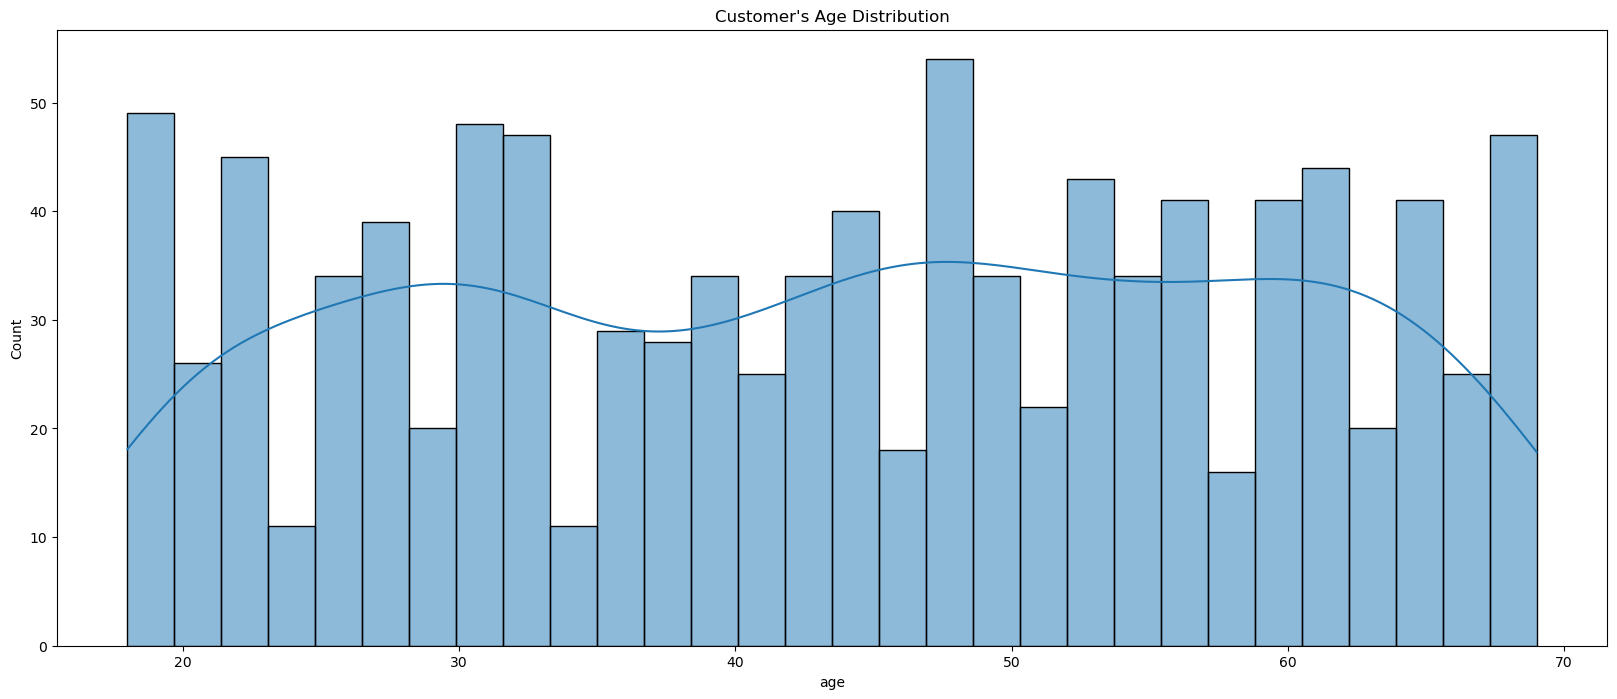

In [28]:
plt.figure(figsize=(20, 8))
p = sns.histplot(df['age'], kde=True, bins=30)
p.axes.set_title("Customer's Age Distribution")
plt.show()

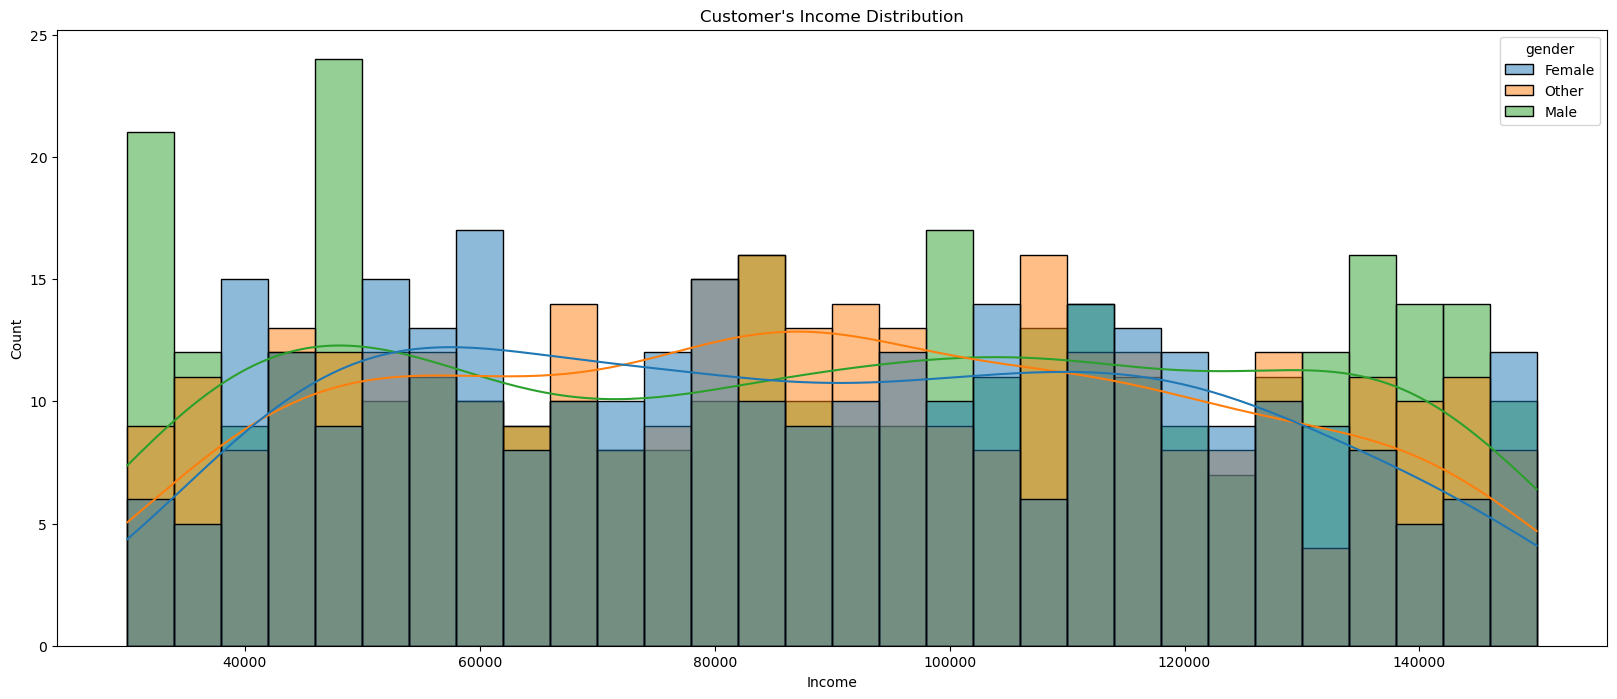

In [29]:
plt.figure(figsize=(20, 8))
p = sns.histplot(data=df, x='income', kde=True, bins=30, hue= 'gender')
p.axes.set_title("Customer's Income Distribution")
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

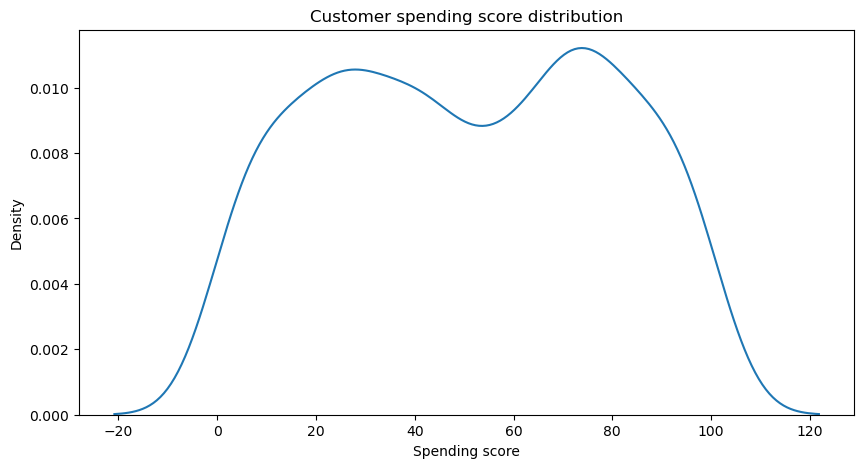

In [30]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['spending_score'])
plt.title('Customer spending score distribution')
plt.xlabel('Spending score')
plt.ylabel('Density')
plt.show()

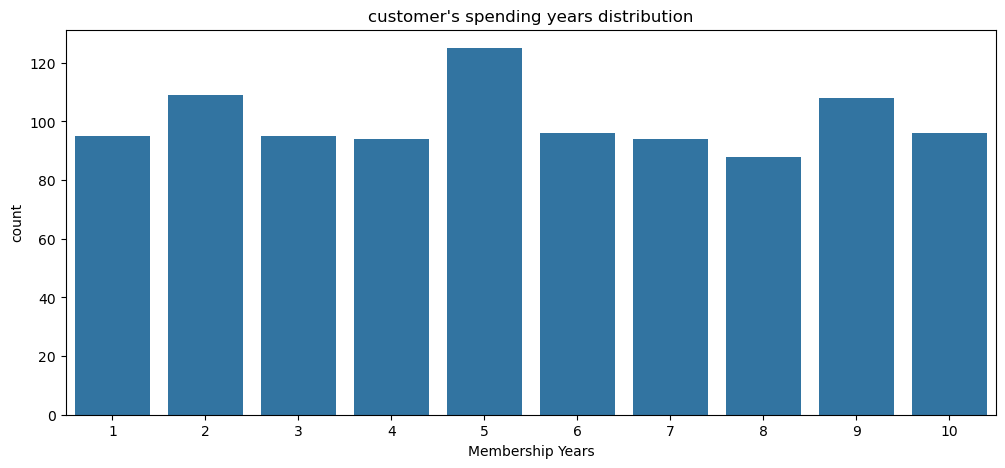

In [31]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='membership_years')
plt.title('customer\'s spending years distribution')
plt.xlabel("Membership Years")
plt.ylabel('count')
plt.show()


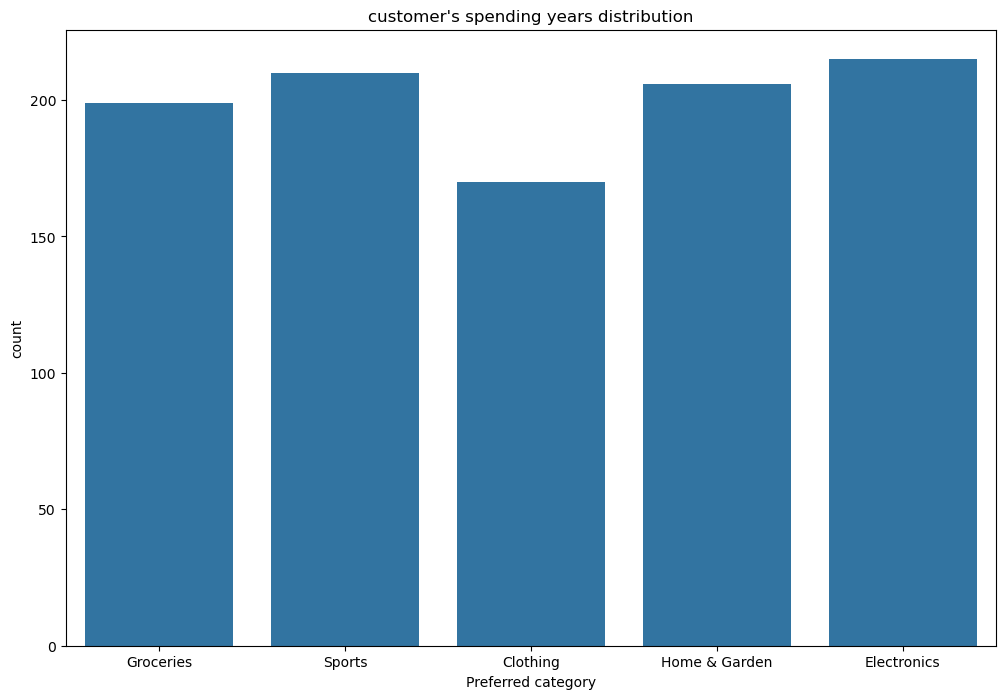

In [32]:
plt.figure(figsize=(12, 8))
p= sns.countplot(data=df, x='preferred_category')
plt.title('customer\'s spending years distribution')
plt.xlabel("Preferred category")
plt.ylabel('count')
plt.show()

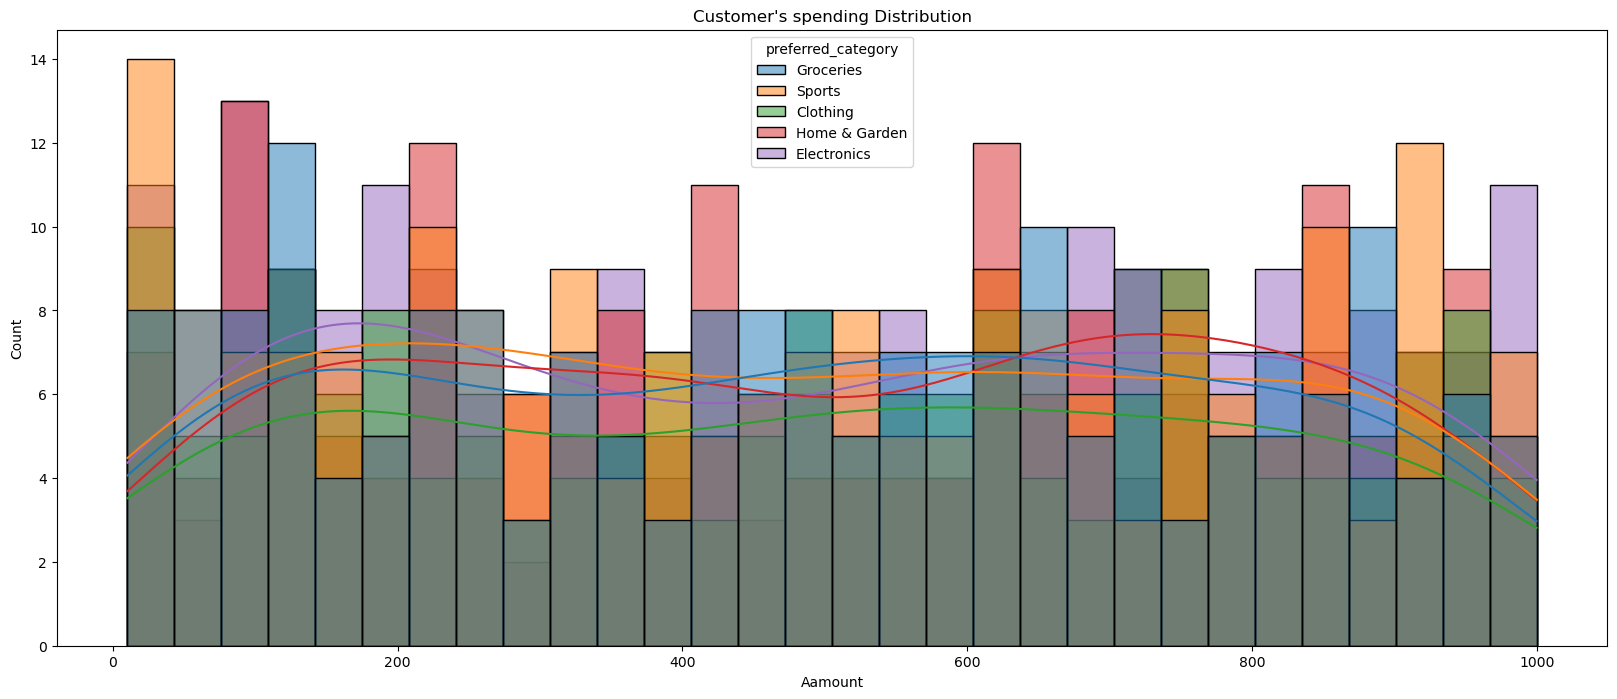

In [33]:
plt.figure(figsize=(20, 8))
p = sns.histplot(data=df, x='last_purchase_amount', kde=True, bins=30, hue= 'preferred_category')
p.axes.set_title("Customer's spending Distribution")
plt.xlabel('Aamount')
plt.ylabel('Count')
plt.show()

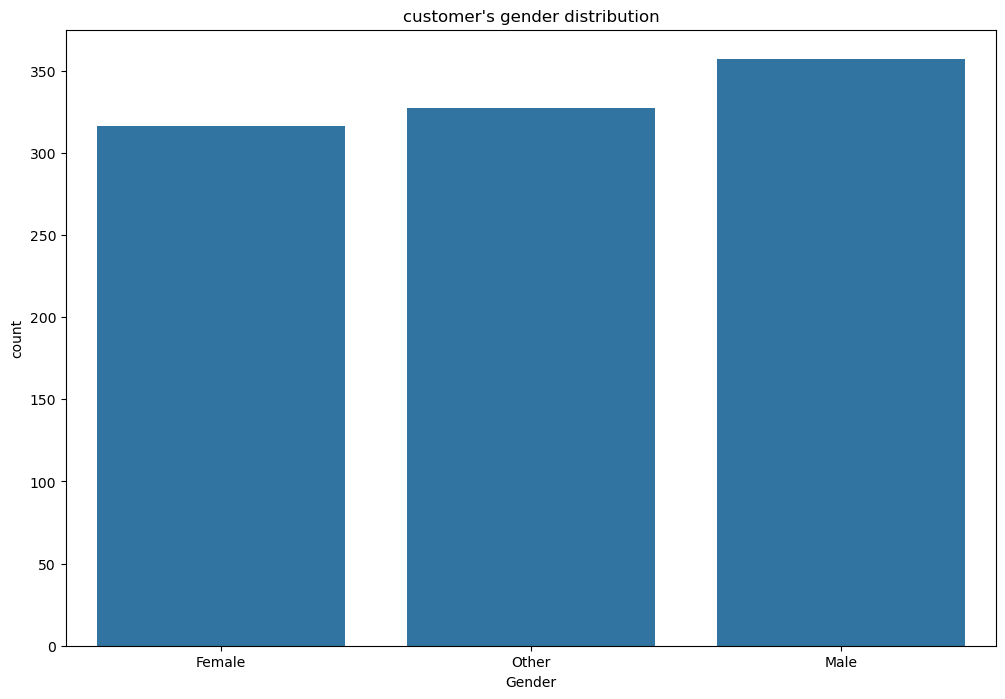

In [34]:
plt.figure(figsize=(12, 8))
p= sns.countplot(data=df, x='gender')
plt.title('customer\'s gender distribution')
plt.xlabel("Gender")
plt.ylabel('count')
plt.show()

In [35]:
le = LabelEncoder()
df_Kmeans = df.copy()
for cols in columns:
    if df[cols].dtype == 'object':
        df_Kmeans[cols] = le.fit_transform(df[cols])

In [36]:
ss = StandardScaler()
df_Kmeans = ss.fit_transform(df_Kmeans)

In [37]:
km = KMeans(n_clusters=5, random_state=42)
pred = km.fit_predict(df_Kmeans)
df['clusters'] = pred

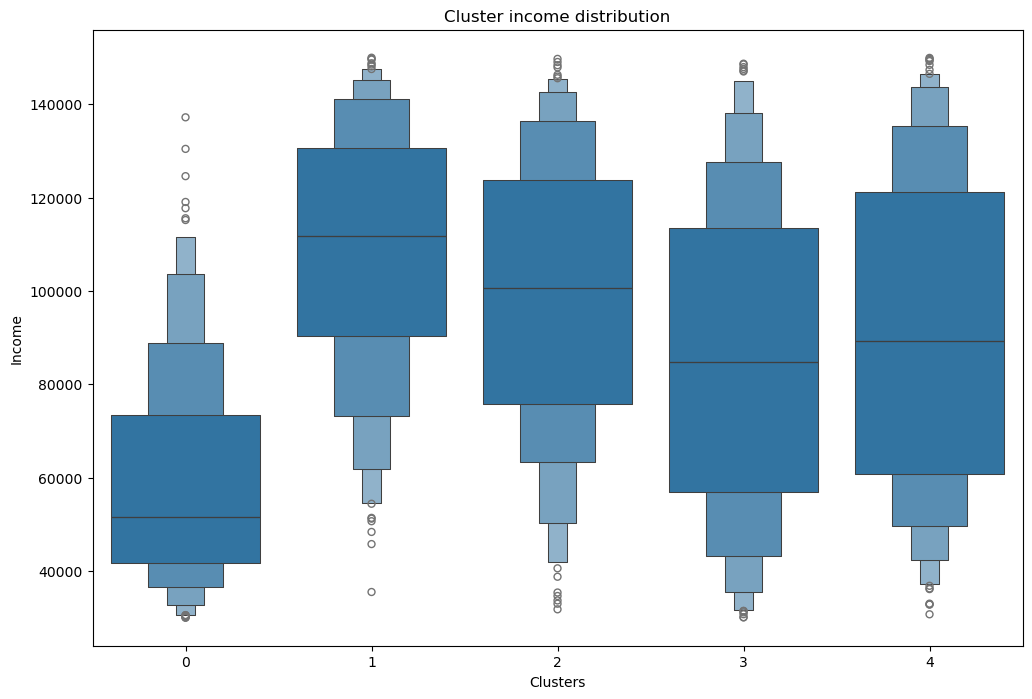

In [38]:
plt.figure(figsize=(12, 8))
sns.boxenplot(data=df, x='clusters', y = 'income')
plt.title('Cluster income distribution')
plt.xlabel('Clusters')
plt.ylabel('Income')

plt.show()

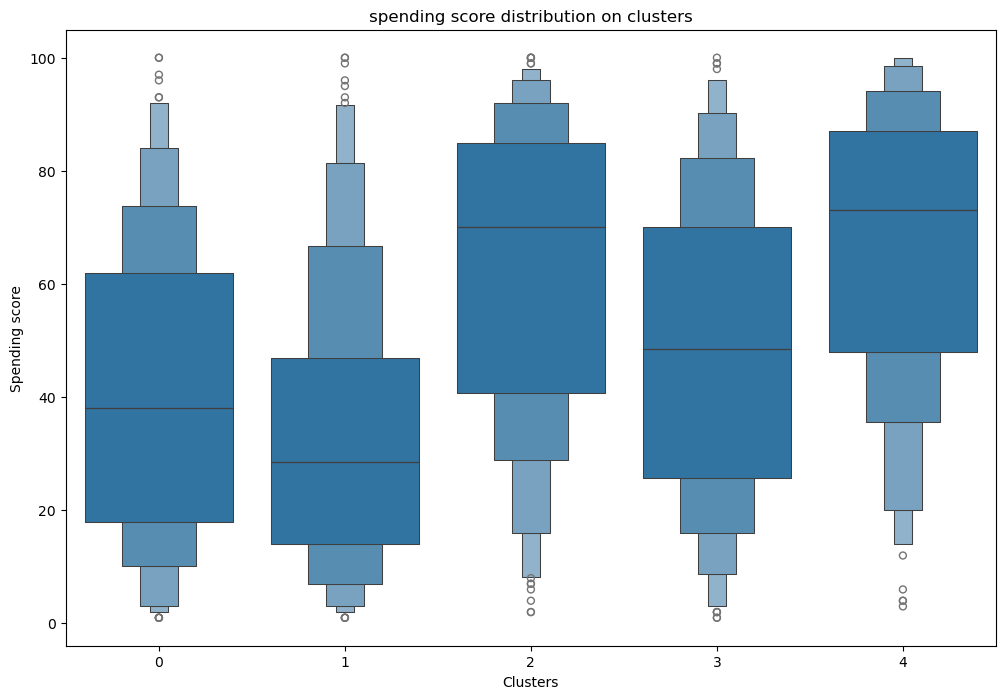

In [39]:
plt.figure(figsize=(12, 8))
sns.boxenplot(data=df, x='clusters', y = 'spending_score')
plt.title('spending score distribution on clusters')
plt.xlabel('Clusters')
plt.ylabel('Spending score')
plt.show()

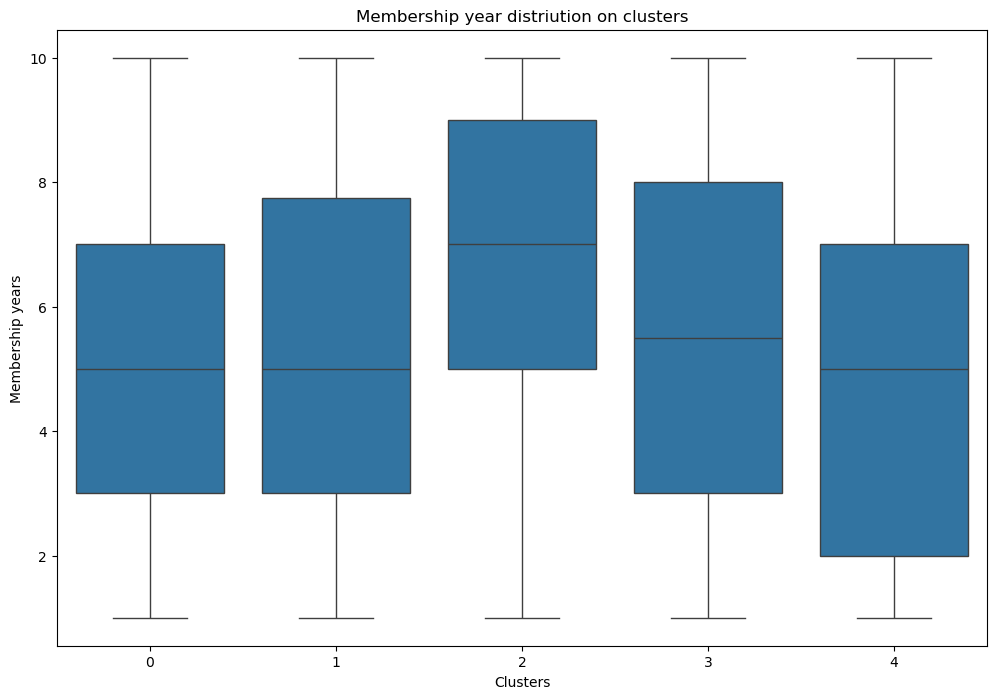

In [40]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='clusters', y = 'membership_years')
plt.title('Membership year distriution on clusters')
plt.xlabel('Clusters')
plt.ylabel('Membership years')
plt.show()

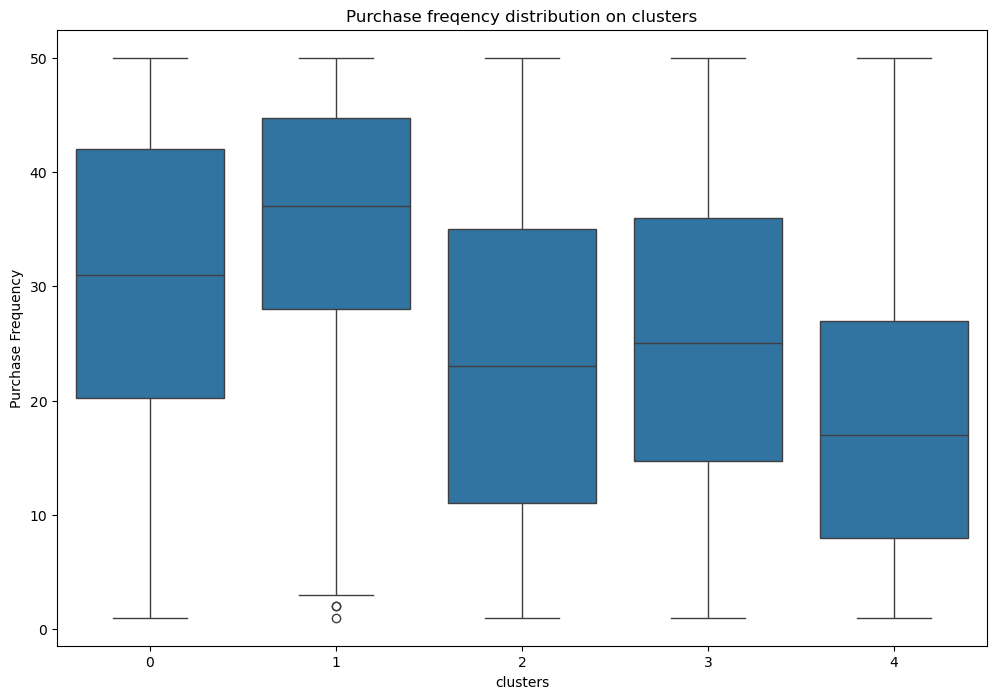

In [41]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='clusters', y = 'purchase_frequency')
plt.title('Purchase freqency distribution on clusters')
plt.xlabel("clusters")
plt.ylabel('Purchase Frequency')
plt.show()

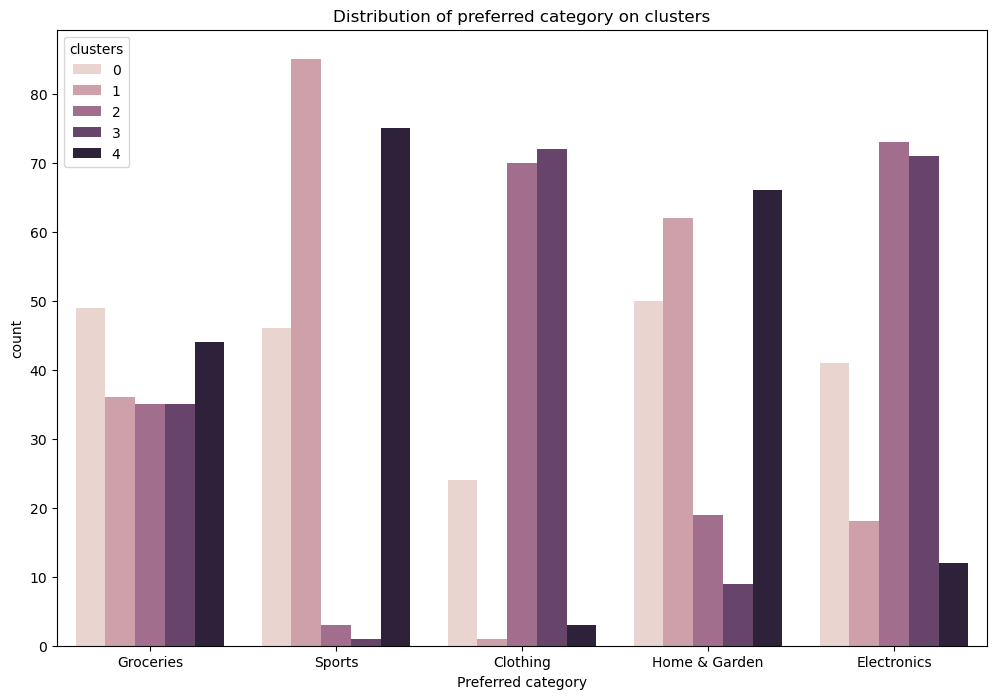

In [42]:
plt.figure(figsize=(12, 8))
p = sns.countplot(data=df, x='preferred_category', hue='clusters')
plt.title('Distribution of preferred category on clusters')
plt.xlabel('Preferred category')
plt.show()

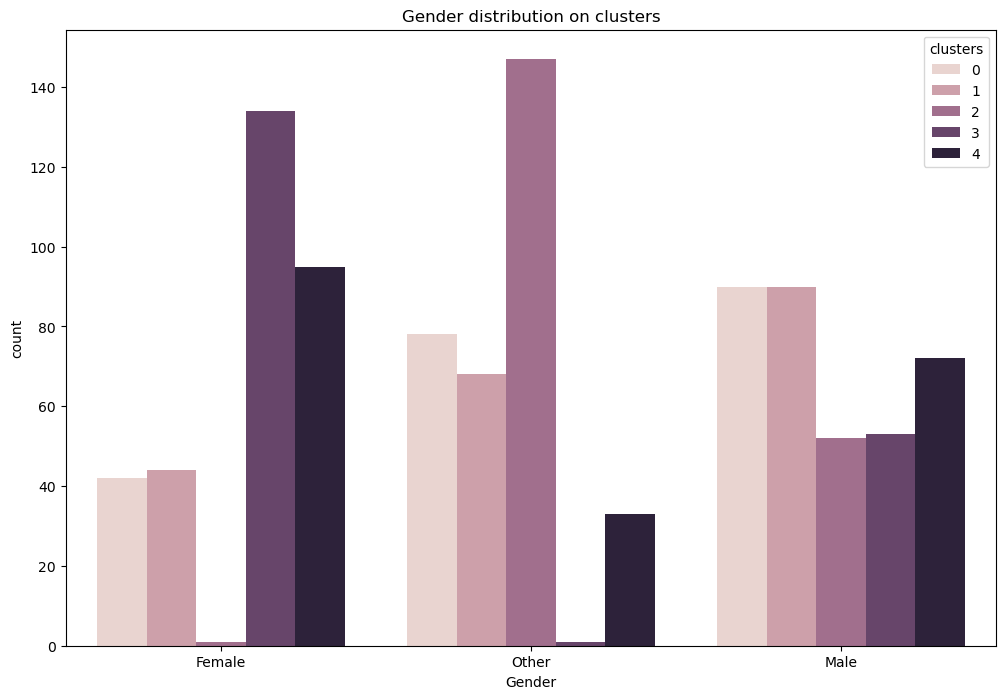

In [43]:
plt.figure(figsize=(12, 8))
p = sns.countplot(data=df, x='gender', hue='clusters')
plt.title("Gender distribution on clusters")
plt.xlabel("Gender")
plt.show()

##  Project Summary

This project uses **K-Means Clustering**, an **unsupervised Machine Learning algorithm**, to segment customers into groups based on their demographic and purchasing behavior.

The code loads and analyzes the customer dataset, preprocesses the features, applies K-Means clustering, and helps identify customers with similar characteristics.

**In short:** This is an **Unsupervised Machine Learning project for Customer Segmentation using K-Means Clustering.**
